# Exploratory Data Analysis (EDA) - MIMIC-IV
This notebook demonstrates a rigorous, manual approach to exploring the MIMIC-IV clinical dataset. We will:
1. Load and inspect multiple datasets.
2. Perform deep data quality profiling.
3. Engineer new features (e.g., diagnoses count per patient).
4. Visualize distributions, relationships, and multi-variable correlations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a highly professional visual theme
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Data Ingestion & Initial Inspection
We begin by loading the core demographic and diagnostic datasets.

In [2]:
# Load raw datasets
patients_df = pd.read_csv('input/data/mimic-iv-clinical-database-demo-2.2/hosp/patients.csv')
diagnoses_df = pd.read_csv('input/data/mimic-iv-clinical-database-demo-2.2/hosp/diagnoses_icd.csv')
lookup_df = pd.read_csv('input/data/mimic-iv-clinical-database-demo-2.2/hosp/d_icd_diagnoses.csv')

print(f"Patients Records: {patients_df.shape[0]}")
print(f"Diagnoses Records: {diagnoses_df.shape[0]}")

# Display the first few rows of each dataset
display(patients_df.head())
display(diagnoses_df.head())
display(lookup_df.head())

Patients Records: 100
Diagnoses Records: 4506


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10035185,22580999,3,4139,9
1,10035185,22580999,10,V707,9
2,10035185,22580999,1,41401,9
3,10035185,22580999,9,3899,9
4,10035185,22580999,11,V8532,9


,icd_code,icd_version,long_title
0,0090,9,"Infectious colitis, enteritis, and gastroenter..."
1,01160,9,"Tuberculous pneumonia [any form], unspecified"
2,01186,9,"Other specified pulmonary tuberculosis, tuberc..."
3,01200,9,"Tuberculous pleurisy, unspecified"
4,01236,9,"Tuberculous laryngitis, tubercle bacilli not f..."


## 2. Manual Data Quality Profiling
Instead of trusting the data blindly, we must inspect columns for missing values, data types, and logical bounds.

In [3]:
# 2a. Inspecting Data Types and Non-Null Counts
print("--- PATIENTS INFO ---")
patients_df.info()
print("\n--- DIAGNOSES INFO ---")
diagnoses_df.info()

--- PATIENTS INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subject_id         100 non-null    int64
 1   gender             100 non-null    str  
 2   anchor_age         100 non-null    int64
 3   anchor_year        100 non-null    int64
 4   anchor_year_group  100 non-null    str  
 5   dod                31 non-null     str  
dtypes: int64(3), str(3)
memory usage: 6.3 KB

--- DIAGNOSES INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 4506 entries, 0 to 4505
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   subject_id   4506 non-null   int64
 1   hadm_id      4506 non-null   int64
 2   seq_num      4506 non-null   int64
 3   icd_code     4506 non-null   str  
 4   icd_version  4506 non-null   int64
dtypes: int64(4), str(1)
memory usage: 196.1 KB


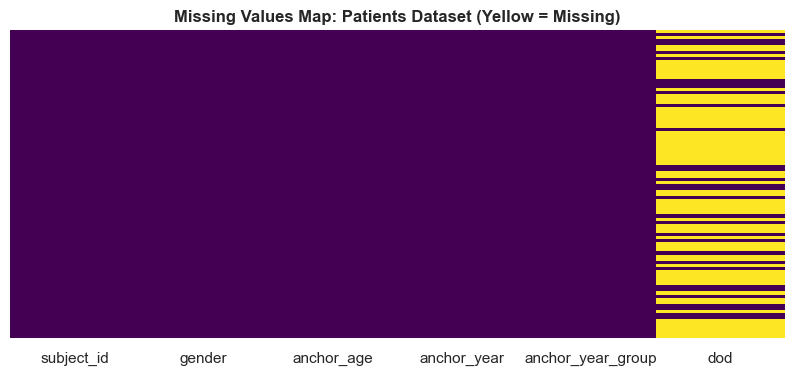

In [4]:
# 2b. Missing Value Heatmap
# Visualizing where data is missing helps identify systemic data collection issues.
plt.figure(figsize=(10, 4))
sns.heatmap(patients_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Map: Patients Dataset (Yellow = Missing)", fontweight='bold')
plt.show()

# We can see 'dod' (Date of Death) is missing for many, which logically means the patient is alive.

### 2c. Explicit Data Quality Validation
To ensure pipeline robustness, we programmatically check for anomalies such as invalid categorical values, out-of-bounds numerics, and referential integrity issues.

In [5]:
# 1. Invalid Categorical Values: Gender
invalid_genders = patients_df[~patients_df['gender'].isin(['M', 'F'])]
print(f"Records with invalid gender: {len(invalid_genders)}")

# 2. Out-of-Bounds Numerics: Age
invalid_ages = patients_df[(patients_df['anchor_age'] < 0) | (patients_df['anchor_age'] > 120)]
print(f"Records with invalid age (<0 or >120): {len(invalid_ages)}")

# 3. Referential Integrity: Orphaned Diagnoses
# Check if there are any diagnoses associated with a patient not in our patients_df
orphaned_diagnoses = diagnoses_df[~diagnoses_df['subject_id'].isin(patients_df['subject_id'])]
print(f"Diagnoses without a matching patient record: {len(orphaned_diagnoses)}")

# 4. Check for duplicates
print(f"Duplicate patient records: {patients_df.duplicated().sum()}")
print(f"Duplicate diagnosis records: {diagnoses_df.duplicated().sum()}")


Records with invalid gender: 0
Records with invalid age (<0 or >120): 0
Diagnoses without a matching patient record: 0
Duplicate patient records: 0
Duplicate diagnosis records: 0


## 3. Feature Engineering & Dataset Joining
To find interesting relationships, we need to combine data from multiple tables. We will calculate the total number of diagnoses for each patient and merge it into the demographic table.

In [6]:
# Calculate total diagnoses per patient
diag_counts = diagnoses_df.groupby('subject_id').size().reset_index(name='total_diagnoses')

# Merge this into the patients dataframe
df_merged = pd.merge(patients_df, diag_counts, on='subject_id', how='left')

# Create a clear 'Mortality' boolean flag based on the 'dod' column
df_merged['is_deceased'] = df_merged['dod'].notna()

df_merged.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,total_diagnoses,is_deceased
0,10014729,F,21,2125,2011 - 2013,NaN,20,False
1,10003400,F,72,2134,2011 - 2013,2137-09-02,153,True
2,10002428,F,80,2155,2011 - 2013,NaN,114,False
3,10032725,F,38,2143,2011 - 2013,2143-03-30,37,True
4,10027445,F,48,2142,2011 - 2013,2146-02-09,55,True


In [7]:
# Let's look at the statistical summary of our numerical columns
df_merged[['anchor_age', 'total_diagnoses']].describe()

,anchor_age,total_diagnoses
count,100.00000,100.000000
mean,61.75000,45.060000
std,16.16979,63.597983
min,21.00000,3.000000
25%,51.75000,11.000000
50%,63.00000,22.000000
75%,72.00000,48.250000
max,91.00000,447.000000


## 4. Advanced Visualizations & Insights
Now that our data is clean and merged, we can explore multi-dimensional relationships.

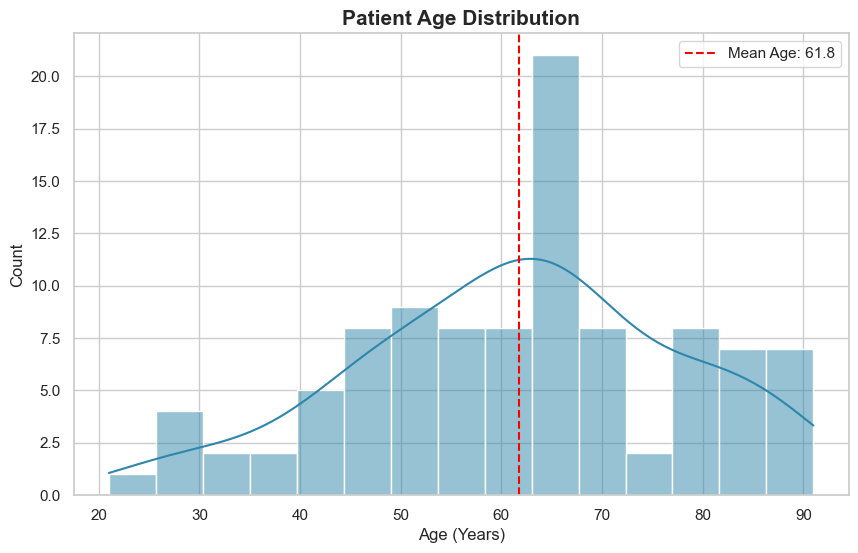

In [8]:
# 4a. Distribution of Age (Histogram + KDE)
plt.figure(figsize=(10, 6))
sns.histplot(data=df_merged, x="anchor_age", bins=15, kde=True, color="#2E86AB")
plt.title("Patient Age Distribution", fontsize=15, fontweight='bold')
plt.xlabel("Age (Years)")
plt.ylabel("Count")
plt.axvline(df_merged['anchor_age'].mean(), color='red', linestyle='--', label=f"Mean Age: {df_merged['anchor_age'].mean():.1f}")
plt.legend()
plt.show()

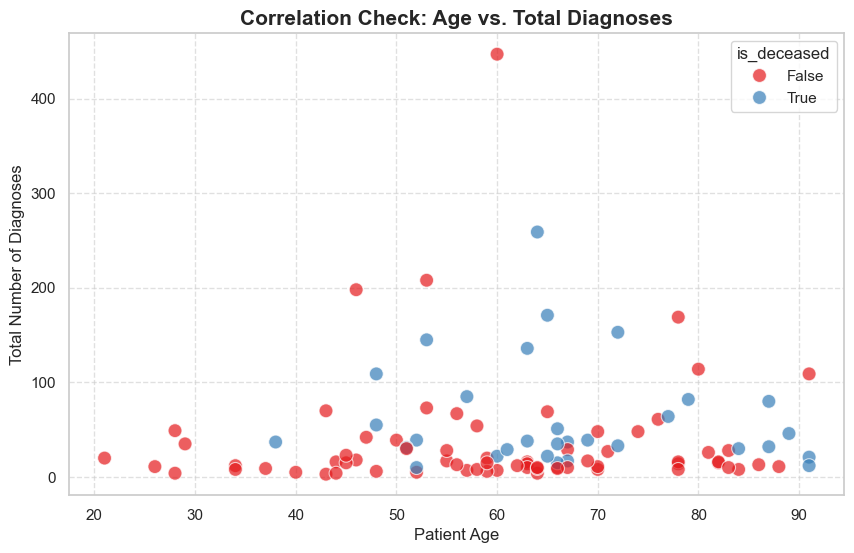

In [9]:
# 4b. Scatter Plot: Age vs. Number of Diagnoses
# Does age correlate with a higher number of hospital diagnoses?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged, x="anchor_age", y="total_diagnoses", hue="is_deceased", palette="Set1", s=100, alpha=0.7)
plt.title("Correlation Check: Age vs. Total Diagnoses", fontsize=15, fontweight='bold')
plt.xlabel("Patient Age")
plt.ylabel("Total Number of Diagnoses")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

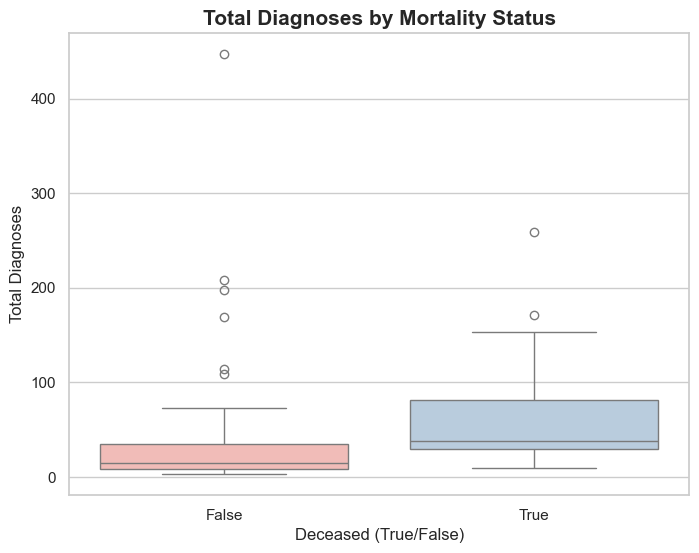

In [10]:
# 4c. Boxplot: Comparing Mortality vs. Diagnosis Count
# Are deceased patients likely to have had more diagnoses?
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_merged, x="is_deceased", y="total_diagnoses", hue="is_deceased", palette="Pastel1", legend=False)
plt.title("Total Diagnoses by Mortality Status", fontsize=15, fontweight='bold')
plt.xlabel("Deceased (True/False)")
plt.ylabel("Total Diagnoses")
plt.show()

## 5. Mortality Deep Dive & Patterns
Let's take a more humanistic approach to see what happens when patients pass away. We will explore the mortality distribution across months and investigate the leading diagnoses for patients who didn't survive.

In [11]:
df_merged[df_merged['is_deceased']].copy()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,total_diagnoses,is_deceased
1,10003400,F,72,2134,2011 - 2013,2137-09-02,153,True
3,10032725,F,38,2143,2011 - 2013,2143-03-30,37,True
4,10027445,F,48,2142,2011 - 2013,2146-02-09,55,True
7,10040025,F,64,2143,2011 - 2013,2148-02-07,259,True
9,10020640,F,91,2153,2011 - 2013,2154-02-04,21,True
16,10019003,F,65,2148,2011 - 2013,2155-12-03,171,True
17,10002930,F,48,2193,2011 - 2013,2201-12-24,109,True
18,10010471,F,89,2155,2014 - 2016,2155-12-07,46,True
20,10031757,F,67,2137,2014 - 2016,2137-10-31,37,True
24,10000032,F,52,2180,2014 - 2016,2180-09-09,39,True


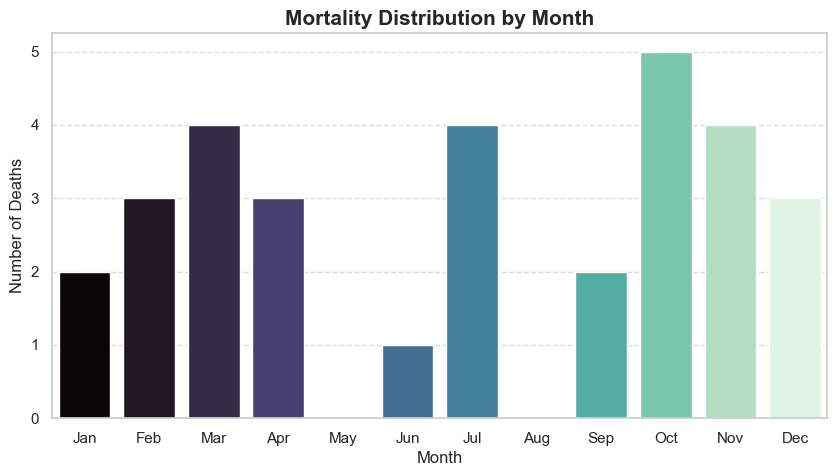

In [15]:
# 5a. Mortality Distribution by Month
# Let's check if there are specific months with higher mortality rates.
df_merged['dod'] = pd.to_datetime(df_merged['dod'])
deceased_patients = df_merged[df_merged['is_deceased']].copy()
deceased_patients['death_month'] = deceased_patients['dod'].dt.month

plt.figure(figsize=(10, 5))
month_counts = deceased_patients['death_month'].value_counts().reindex(range(1, 13), fill_value=0)
sns.barplot(x=month_counts.index, y=month_counts.values, hue=month_counts.index, palette='mako', legend=False)
plt.title('Mortality Distribution by Month', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Deaths')
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

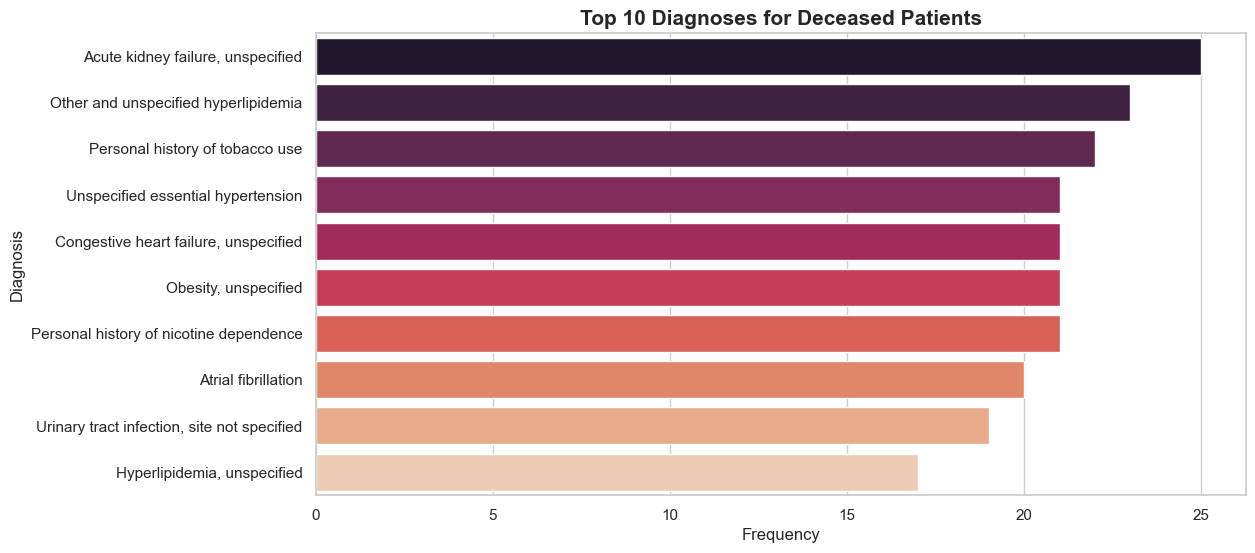

In [13]:
# 5b. Leading Causes of Death
# We will filter the diagnoses for deceased patients and find the most common ICD codes.
deceased_subject_ids = deceased_patients['subject_id']
deceased_diagnoses = diagnoses_df[diagnoses_df['subject_id'].isin(deceased_subject_ids)]

# Merge with lookup table to get human-readable long titles
deceased_diagnoses_with_titles = pd.merge(deceased_diagnoses, lookup_df, on=['icd_code', 'icd_version'], how='left')

top_causes = deceased_diagnoses_with_titles['long_title'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(y=top_causes.index, x=top_causes.values, hue=top_causes.index, palette='rocket', legend=False)
plt.title('Top 10 Diagnoses for Deceased Patients', fontsize=15, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Diagnosis')
plt.show()

## 6. Hospital Visits & Mortality
We can determine the total number of hospital visits per patient by counting the unique Hospital Admission IDs (`hadm_id`). Let's see how the number of visits relates to mortality.

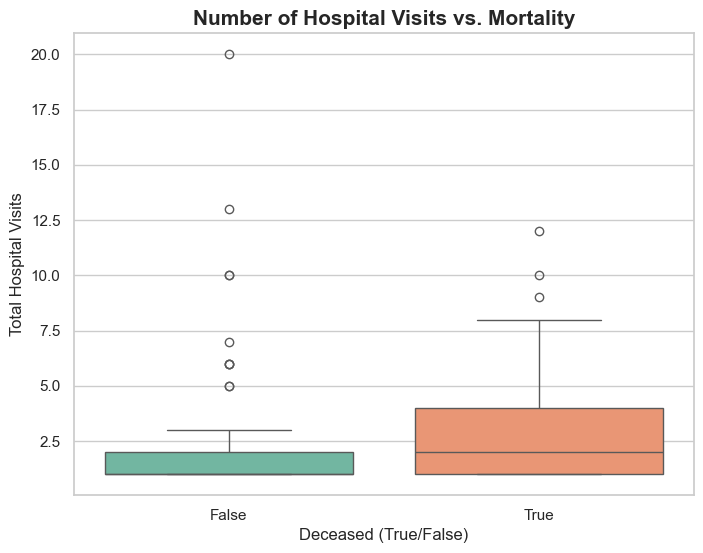

,count,mean,std,min,25%,50%,75%,max
is_deceased,,,,,,,,
False,69.0,2.492754,3.197532,1.0,1.0,1.0,2.0,20.0
True,31.0,3.322581,3.113274,1.0,1.0,2.0,4.0,12.0


In [14]:
# Calculate total unique hospital visits per patient
visits_df = diagnoses_df.groupby('subject_id')['hadm_id'].nunique().reset_index(name='total_visits')

# Merge into our main dataframe
df_merged = pd.merge(df_merged, visits_df, on='subject_id', how='left')

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_merged, x='is_deceased', y='total_visits', hue='is_deceased', palette='Set2', legend=False)
plt.title('Number of Hospital Visits vs. Mortality', fontsize=15, fontweight='bold')
plt.xlabel('Deceased (True/False)')
plt.ylabel('Total Hospital Visits')
plt.show()

display(df_merged.groupby('is_deceased')['total_visits'].describe())